In [1]:
import os
from tqdm import tqdm

import scanpy as sc
import anndata as ad
from kneed import KneeLocator

import h5py
from scipy.sparse import csc_matrix
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import omnipath as op

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore', module='pandas')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='ipykernel')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings(action='ignore', category=UserWarning, module='scanpy')

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS import preprocess as pp
from scLEMBAS import io

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
seed = 888

Load the files:

In [3]:
h5_file = os.path.join(data_path, 'raw', 'kang_2017_raw_counts.h5')
with h5py.File(h5_file, "r") as f:
    data = f["data"][:]
    indices = f["i"][:]
    indptr = f["p"][:]
    dims = f["dims"][:]
    
    row_names = list(f["rownames"][:].astype(str))
    col_names = list(f["colnames"][:].astype(str))

sparse_matrix = csc_matrix((data, indices, indptr), shape=(dims[0], dims[1]))
expr = pd.DataFrame.sparse.from_spmatrix(sparse_matrix, index=row_names, columns=col_names)
md = pd.read_csv(os.path.join(data_path, 'raw', 'kan_2017_md.csv'), index_col = 0)
adata = sc.AnnData(X = expr.T, obs = md)

QC:

In [4]:
# adata.var["mt"] = adata.var_names.str.startswith("MT-")
# sc.pp.calculate_qc_metrics(
#     adata, qc_vars=["mt"], inplace=True, log1p=True
# )


# sc.pl.violin(
#     adata,
#     ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
#     jitter=0.4,
#     multi_panel=True,
# )

sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

Normalize:

In [6]:
adata.layers["counts"] = adata.X.copy() # store the raw data
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)

Select HVGs:

In [7]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key=None, flavor = 'seurat')

Scale:

In [8]:
scaled_adata = sc.pp.scale(adata, copy = True)
adata.layers['scaled_data']  = scaled_adata.X.copy() # store the scaled data
del scaled_adata

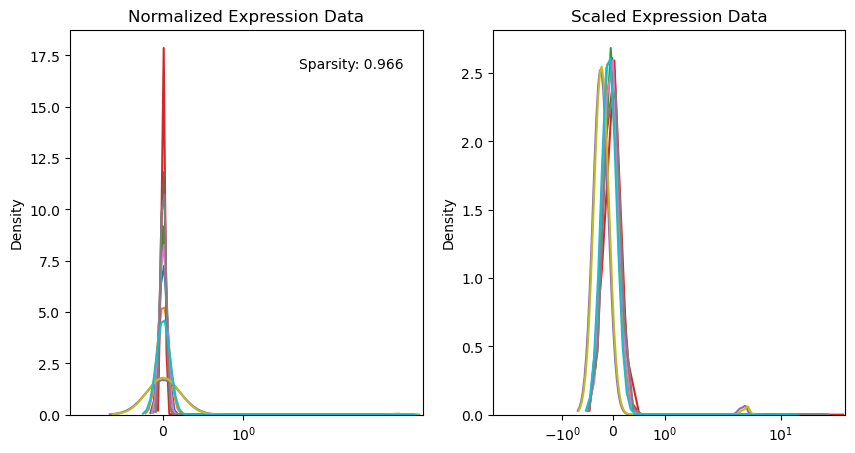

In [9]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))

adata_ = adata[:, adata.var[adata.var['highly_variable']].index]
expr = adata_.to_df()
sparsity = (expr == 0).sum().sum() / expr.size

scaled_expr = pd.DataFrame(adata_.layers['scaled_data'], 
            index = adata_.obs.index.tolist(), 
            columns = adata_.var_names.tolist())

subset = 10
np.random.seed(seed)
select_features = np.random.choice(expr.columns.tolist(), replace = False, size = 10)
# select_features = np.random.choice(adata.var['highly_variable'].index.tolist(), replace = False, size = 10)


for feature in select_features:
    sns.kdeplot(expr[feature].values, ax = ax[0])
    sns.kdeplot(scaled_expr[feature].values, ax = ax[1])
    
ax[0].set_title('Normalized Expression Data')
ax[0].annotate('Sparsity: {:.3f}'.format(sparsity), 
              xy = (0.65, 0.9), xycoords = 'axes fraction')

ax[1].set_title('Scaled Expression Data')

for i in range(2):
    ax[i].set_xscale('symlog')

Embed:

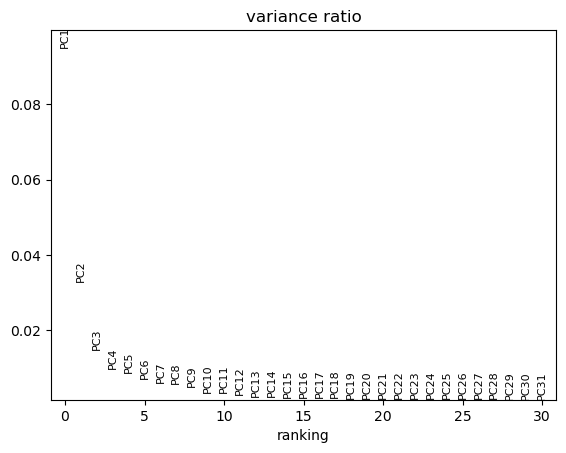

The elbow was automatically identified at PC 4


In [10]:
sc.tl.pca(adata, 
          zero_center = True, # rather than used scaled data, calculates covariance matrix internally; default pipeline does not scale but does zero-center
          n_comps = 50,
          random_state = seed, 
          use_highly_variable = True,
         )

variance_ratio = adata.uns['pca']['variance_ratio']
pcs = np.array(range(len(variance_ratio))) + 1
kneedle = KneeLocator(x = pcs, y = variance_ratio, curve='convex', direction='decreasing')
adata.uns['pca']['pca_rank'] = kneedle.elbow

sc.pp.neighbors(adata, n_pcs = adata.uns['pca']['pca_rank'])
sc.tl.umap(adata)

sc.tl.leiden(adata, flavor="igraph", n_iterations=2, 
             resolution = 2.5 # adjusted to be near the number of clusters identified by seurat by original paper
            )
adata.write_h5ad(os.path.join(data_path, 'interim', 'kang_embedded.h5ad'))

adata = sc.read_h5ad(os.path.join(data_path, 'interim', 'kang_embedded.h5ad'))

sc.pl.pca_variance_ratio(adata)
print('The elbow was automatically identified at PC {}'.format(adata.uns['pca']['pca_rank']))


In [11]:
adata.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,stim,seurat_annotations,n_genes,leiden
AAACATACATTTCC.1,IMMUNE_CTRL,3017,877,CTRL,CD14 Mono,877,0
AAACATACCAGAAA.1,IMMUNE_CTRL,2481,713,CTRL,CD14 Mono,713,3
AAACATACCTCGCT.1,IMMUNE_CTRL,3420,850,CTRL,CD14 Mono,850,2
AAACATACCTGGTA.1,IMMUNE_CTRL,3156,1109,CTRL,pDC,1109,7
AAACATACGATGAA.1,IMMUNE_CTRL,1868,634,CTRL,CD4 Memory T,634,12


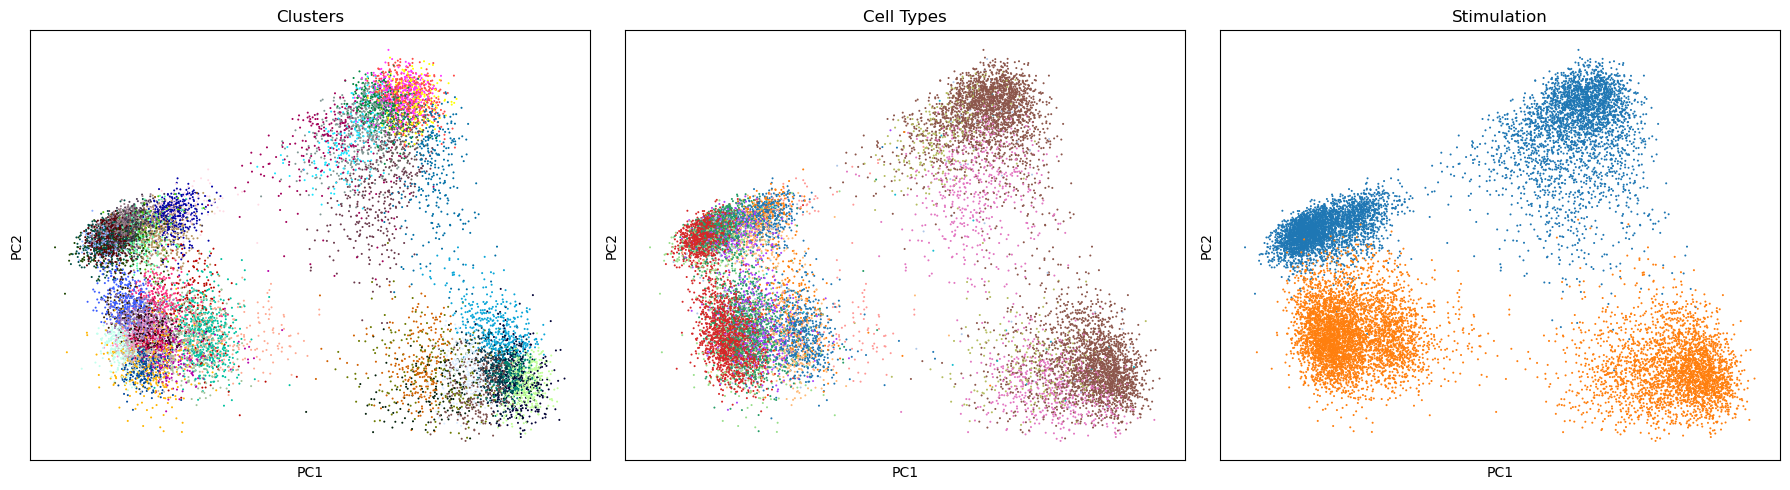

In [12]:
fig, ax = plt.subplots(ncols = 3, figsize = (18, 5))

sc.pl.pca(adata, color='leiden', ax = ax[0], show = False)
ax[0].set_title('Clusters')
ax[0].legend().set_visible(False)
# ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.pca(adata, color='seurat_annotations', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
ax[1].legend().set_visible(False)

sc.pl.pca(adata, color='stim', ax = ax[2], show = False)
ax[2].set_title('Stimulation')
ax[2].legend().set_visible(False)
# ax[2].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_adata.obs.TF_clusters, tf_adata.obs.celltype)),
#                 xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

PC 2 is separating on stimulation, and PC 1 on cell type, which is good.

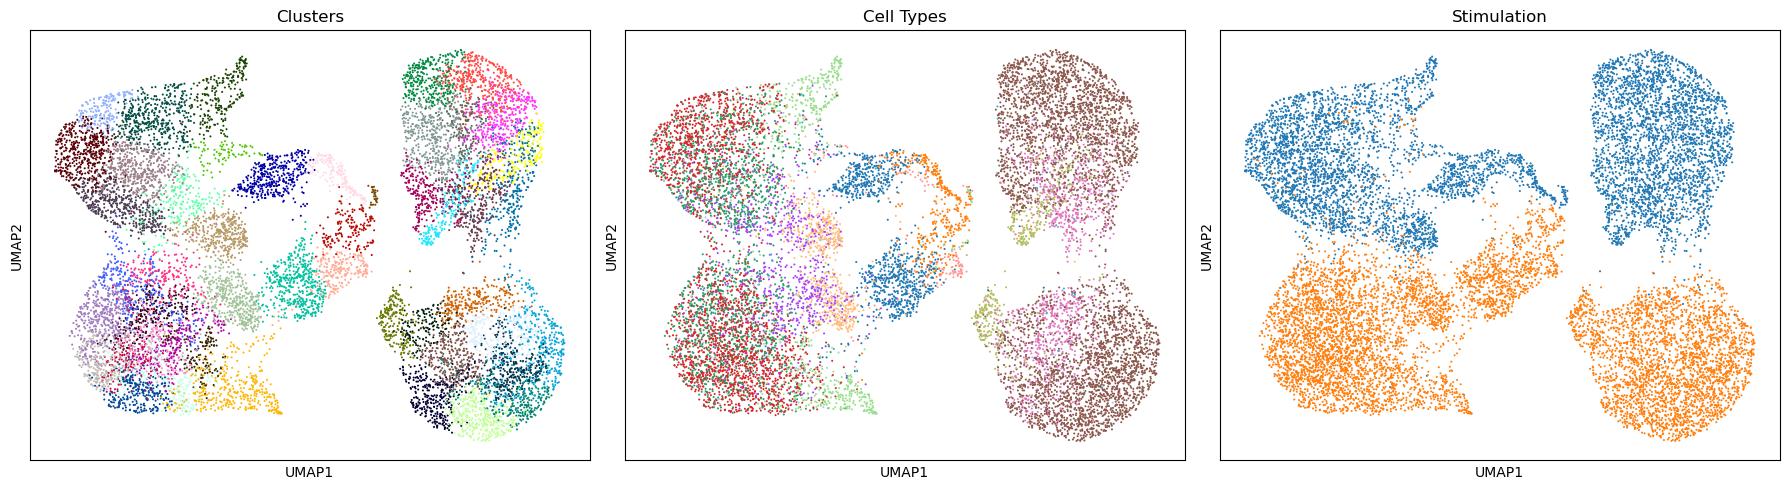

In [13]:
fig, ax = plt.subplots(ncols = 3, figsize = (18, 5))

sc.pl.umap(adata, color='leiden', ax = ax[0], show = False)
ax[0].set_title('Clusters')
ax[0].legend().set_visible(False)
# ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.umap(adata, color='seurat_annotations', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
ax[1].legend().set_visible(False)

sc.pl.umap(adata, color='stim', ax = ax[2], show = False)
ax[2].set_title('Stimulation')
ax[2].legend().set_visible(False)
# ax[2].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_adata.obs.TF_clusters, tf_adata.obs.celltype)),
#                 xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

A note on batch correction:
    
The original [paper](https://doi.org/10.1038/nbt.4042) pooled samples together. So there isn't batch across stimulation condition or sample. There are batches, but the paper showed gene expression is reproducible across these. Given this, batch effect correction is not necessary. While the Seurat vignette does apply batch effect correction on stimulation condition to this dataset in their vignette, this is just meant as an example of how their method can group like cell types together and wouldn't be appropriate here as it is not the batch condition. 

Get TF activity scores:

In [14]:
kwargs = {'args' : {'wsum' : {'times': int(1e3), 'batch_size': int(1e4)},
                       'ulm' : {'batch_size': int(1e4)}, 
                        'mlm': {'batch_size': int(1e4)}
                       }, 
#          'methods': ['wsum', 'ulm', 'mlm'], 
         'cns_metds': ['ulm_estimate', 'mlm_estimate', 'wsum_estimate']}
# default is wsum_norm, which introduces inf values that result in nan when z-scoring..
# also intuitively doesnt make sense to z-score an already normalized value
# particularly when the other z-scores or on the non-normalized values



adata = pp.get_tf_activity(adata, organism = 'human', grn = 'collectri', verbose = True,
                consensus = True, hvg = True,
                min_n = 5, use_raw = False, filter_pvals = False, pval_thresh = 0.05, **kwargs)

adata.write_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))

Running scores.
Running mlm on mat with 13999 samples and 5000 targets for 423 sources.


100%|████████████████████████████████████████████████████████████████████| 2/2 [00:05<00:00,  2.52s/it]


Running ulm on mat with 13999 samples and 5000 targets for 423 sources.


100%|████████████████████████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.99it/s]


Running wsum on mat with 13999 samples and 5000 targets for 423 sources.


100%|███████████████████████████████████████████████████████████████████| 2/2 [12:58<00:00, 389.45s/it]


''

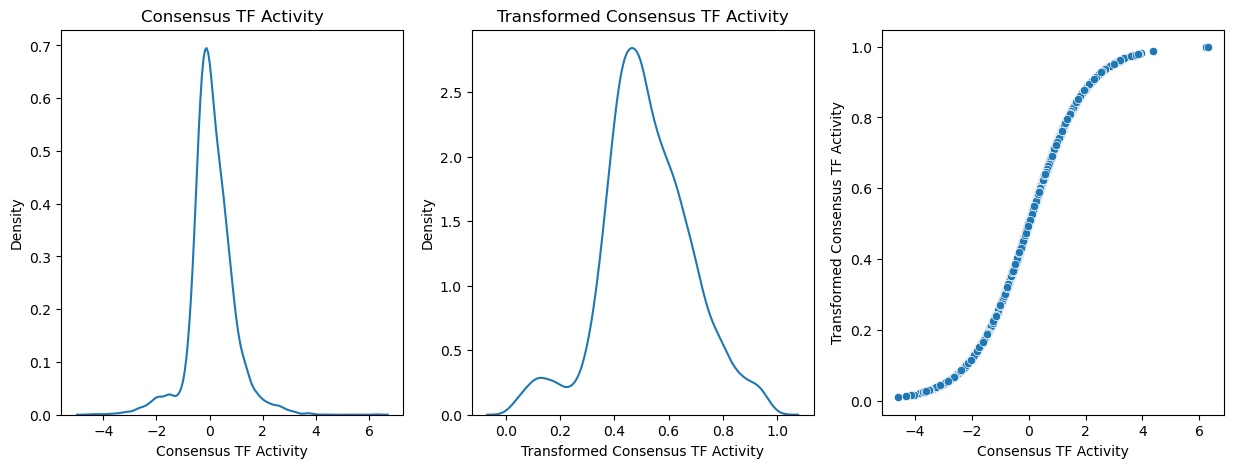

In [15]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))

vals = adata.obsm['consensus_estimate'].values.flatten()
vals_transformed = pp.transform_tf_activity(adata.obsm['consensus_estimate']).values.flatten()
scores = pd.DataFrame(data = {'Consensus TF Activity': vals, 
                    'Transformed Consensus TF Activity': vals_transformed})
scores_subset = scores.sample(n=int(1e4), random_state=seed)


sns.kdeplot(scores_subset['Consensus TF Activity'], ax = ax[0])
ax[0].set_title('Consensus TF Activity')

sns.kdeplot(scores_subset['Transformed Consensus TF Activity'], ax = ax[1])
ax[1].set_title('Transformed Consensus TF Activity')

sns.scatterplot(data = scores_subset, x = 'Consensus TF Activity', 
                y = 'Transformed Consensus TF Activity', ax = ax[2])
;

In [16]:
fn_csv = os.path.join(data_path, 'interim', 'Kang_TF_activity.csv') 

for key in adata.obsm:
    if key.endswith('estimate') or key.endswith('pvals'):
        fn_csv_ = fn_csv.replace('TF_activity', key + '_TF_activity')
        adata.obsm[key].to_csv(fn_csv_)

tf_adata = pp.tf_to_adata(adata, estimate_key = 'consensus_estimate')
io.write_tfad(tf_adata, file_name = os.path.join(data_path, 'interim', 'Kang_tf_activity.h5ad'))